In [4]:
import pandas as pd

# Load data
orders = pd.read_csv("df_Orders.csv")
order_items = pd.read_csv("df_OrderItems.csv")
customers = pd.read_csv("df_Customers.csv")
payments = pd.read_csv("df_Payments.csv")
products = pd.read_csv("df_Products.csv")

# Join data
df = (
    order_items
    .merge(orders, on="order_id", how="inner")
    .merge(customers, on="customer_id", how="inner")
    .merge(products, on="product_id", how="inner")
    .merge(payments, on="order_id", how="inner")
)

# Select columns only
selected_columns = [
    "order_id",
    "customer_id",
    "order_status",

    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_timestamp",
    "order_estimated_delivery_date",

    "customer_city",
    "customer_state",

    "product_id",
    "product_category_name",
    "seller_id",

    "price",
    "shipping_charges",

    "payment_sequential",
    "payment_type",
    "payment_installments",
    "payment_value"
]

df_final = df[selected_columns]

# Export to CSV
df_final.to_csv("powerbi_ecommerce_dashboard.csv", index=False)

print("Done! File exported: powerbi_ecommerce_dashboard.csv")
print("Rows:", df_final.shape[0])
print("Columns:", df_final.shape[1])

Done! File exported: powerbi_ecommerce_dashboard.csv
Rows: 2529486
Columns: 18


In [3]:
import pandas as pd
df_powerbi = pd.read_csv("powerbi_ecommerce_dashboard.csv")

In [5]:
import pandas as pd

df = pd.read_csv("powerbi_ecommerce_dashboard.csv")

# Số dòng thiếu order_id
missing = df[df["order_id"].isna()]
print(f"Tổng số dòng: {len(df)}")
print(f"Số dòng thiếu order_id: {len(missing)}")

# Các dòng thiếu order_id nhưng vẫn có payment_value
if "payment_value" in df.columns:
    print(f"Trong đó có payment_value: {missing['payment_value'].notna().sum()} dòng")

# Xem các dòng lỗi rơi vào tháng nào
if "order_approved_at" in df.columns:
    missing["order_approved_at"] = pd.to_datetime(missing["order_approved_at"], errors="coerce")
    print(missing["order_approved_at"].dt.to_period("M").value_counts().sort_index())

Tổng số dòng: 2529486
Số dòng thiếu order_id: 0
Trong đó có payment_value: 0 dòng
Series([], Freq: M, Name: count, dtype: int64)


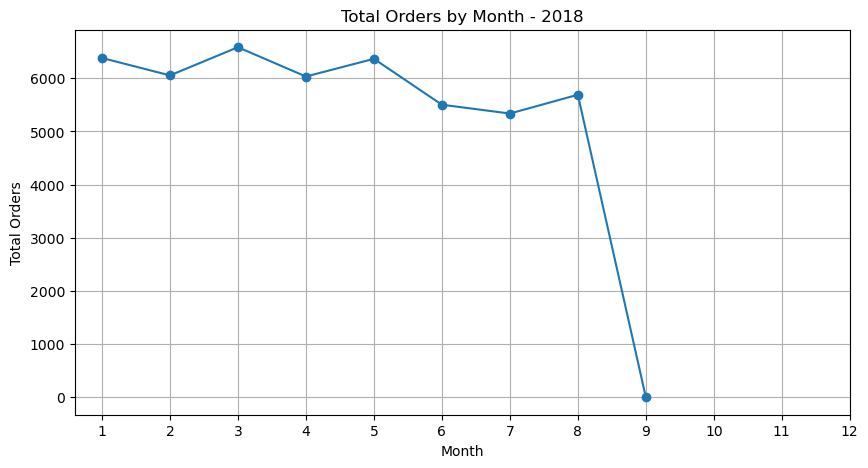

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("powerbi_ecommerce_dashboard.csv")
df["order_approved_at"] = pd.to_datetime(df["order_approved_at"], errors="coerce")

df_2018 = df[df["order_approved_at"].dt.year == 2018]
monthly_orders = df_2018.groupby(df_2018["order_approved_at"].dt.month)["order_id"].nunique()

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")
plt.title("Total Orders by Month - 2018")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

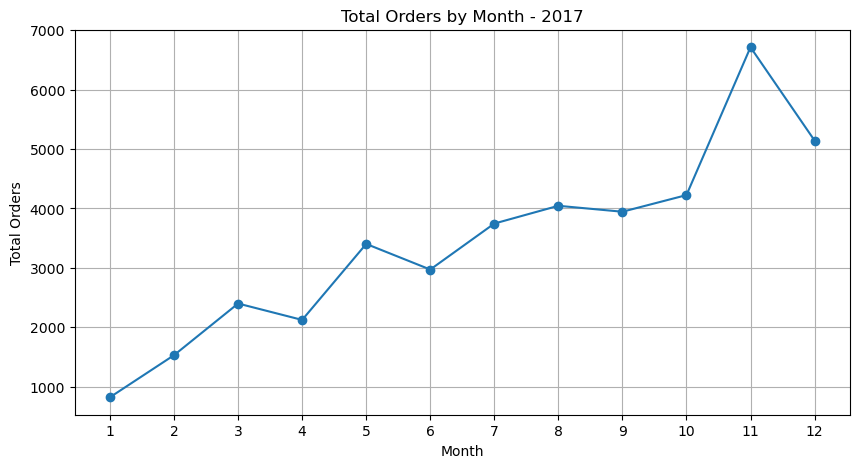

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("powerbi_ecommerce_dashboard.csv")
df["order_approved_at"] = pd.to_datetime(df["order_approved_at"], errors="coerce")

df_2018 = df[df["order_approved_at"].dt.year == 2017]
monthly_orders = df_2018.groupby(df_2018["order_approved_at"].dt.month)["order_id"].nunique()

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")
plt.title("Total Orders by Month - 2017")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()